## Step 1 — Imports & Settings

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Makes all charts appear large and crisp in Jupyter ──
plt.rcParams.update({
    'figure.figsize'   : (11, 5),
    'figure.dpi'       : 120,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 10,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

print("✅ All libraries imported successfully")
print("✅ Inline chart rendering enabled")

✅ All libraries imported successfully
✅ Inline chart rendering enabled


## Step 2 — Load Datasets

In [14]:
# ── UPDATE PATHS IF YOUR FILES ARE IN A DIFFERENT FOLDER ─────────────────────
CUSTOMER_PATH = r"C:\Users\Shree\OneDrive\Desktop\Final Year Project\fashion_marketing_dataset_v2.csv"
CAMPAIGN_PATH = r"C:\Users\Shree\OneDrive\Desktop\Final Year Project\campaign_master.csv"

df_cust = pd.read_csv(CUSTOMER_PATH)
df_camp = pd.read_csv(CAMPAIGN_PATH)

print("=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)
print(f"  Customer dataset : {df_cust.shape[0]} rows × {df_cust.shape[1]} cols")
print(f"  Campaign master  : {df_camp.shape[0]} rows × {df_camp.shape[1]} cols")
print(f"\n  Channels         : {sorted(df_cust['channel'].unique())}")
print(f"  Style segments   : {sorted(df_cust['style_segment'].unique())}")
print(f"  Fashion categories: {sorted(df_cust['fashion_category'].unique())}")
print(f"  Campaigns        : {df_camp['campaign_id'].nunique()} unique IDs")
print(f"  Conversion rate  : {df_cust['conversion_status'].mean()*100:.1f}%")
print("=" * 55)

  DATASET SUMMARY
  Customer dataset : 500 rows × 30 cols
  Campaign master  : 50 rows × 20 cols

  Channels         : ['Email', 'Facebook Ads', 'Google Ads', 'Influencer Marketing', 'Instagram']
  Style segments   : ['Essentials Buyer', 'Luxury Seeker', 'Seasonal Shopper', 'Trendsetter']
  Fashion categories: ['Accessories', 'Ethnic Wear', 'Footwear', 'Western Wear', 'Winter Wear']
  Campaigns        : 50 unique IDs
  Conversion rate  : 28.4%


## Step 3 — Campaign Performance Metrics Table
*Shows ROI, Conversion Rate, CTR, Cost per Conversion for all 50 campaigns*

In [15]:
metric_cols = ['campaign_id', 'channel', 'product_category', 'season',
               'budget', 'conversions', 'roi', 'conversion_rate',
               'ctr', 'cost_per_conversion', 'composite_score']
metric_cols = [c for c in metric_cols if c in df_camp.columns]

display_df = df_camp[metric_cols].copy()

# Format for readability
if 'roi' in display_df.columns:
    display_df['roi'] = display_df['roi'].map('{:.1%}'.format)
if 'conversion_rate' in display_df.columns:
    display_df['conversion_rate'] = display_df['conversion_rate'].map('{:.1%}'.format)
if 'ctr' in display_df.columns:
    display_df['ctr'] = display_df['ctr'].map('{:.2%}'.format)
if 'composite_score' in display_df.columns:
    display_df['composite_score'] = display_df['composite_score'].map('{:.3f}'.format)

print("Campaign Performance Metrics (top 15 shown):")
display(display_df.sort_values('composite_score', ascending=False).head(15)
        .reset_index(drop=True)
        .style.set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector':'th','props':[('background','#1A4A8A'),
                                                      ('color','white'),
                                                      ('text-align','center')]}]))

Campaign Performance Metrics (top 15 shown):


,campaign_id,channel,product_category,season,budget,conversions,roi,conversion_rate,ctr,cost_per_conversion,composite_score
0,FCMP024,Instagram,Footwear,Wedding Season,7911,1483,48246.1%,5.4%,6.16%,5.334457,0.730
1,FCMP016,Influencer Marketing,Winter Wear,Winter,54811,4335,21349.2%,12.7%,7.36%,12.643829,0.719
2,FCMP002,Facebook Ads,Ethnic Wear,Summer,5197,571,34300.6%,10.3%,3.60%,9.101576,0.693
3,FCMP006,Influencer Marketing,Winter Wear,Summer,20087,2222,22156.5%,11.7%,6.26%,9.040054,0.679
4,FCMP034,Instagram,Winter Wear,Winter,42504,2644,20260.0%,9.5%,8.71%,16.075643,0.651
5,FCMP014,Influencer Marketing,Footwear,Summer,20708,1642,17027.3%,10.4%,8.14%,12.611449,0.638
6,FCMP012,Email,Footwear,Summer,49357,2945,8605.5%,11.6%,8.78%,16.759593,0.611
7,FCMP028,Influencer Marketing,Accessories,Summer,24360,2841,6710.9%,11.9%,8.32%,8.574446,0.595
8,FCMP041,Google Ads,Ethnic Wear,Winter,26918,1040,6661.3%,13.7%,5.45%,25.882692,0.585
9,FCMP050,Google Ads,Accessories,Wedding Season,16835,564,3441.1%,12.0%,8.02%,29.849291,0.563


## Step 4 — WSM Normalization & Ranking

In [22]:
def normalize_benefit(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-9)

def normalize_cost(col):
    return (col.max() - col) / (col.max() - col.min() + 1e-9)

# Re-compute WSM in notebook for transparency
df_camp['roi_norm']   = normalize_benefit(df_camp['roi'])
df_camp['cr_norm']    = normalize_benefit(df_camp['conversion_rate'])
df_camp['ctr_norm']   = normalize_benefit(df_camp['ctr'])
df_camp['cpc_norm']   = normalize_cost(df_camp['cost_per_conversion'])

weights = {'roi_norm': 0.40, 'cr_norm': 0.30,
           'ctr_norm': 0.15, 'cpc_norm': 0.15}

df_camp['wsm_score'] = sum(df_camp[col] * w for col, w in weights.items())
ranked_df = df_camp.sort_values('wsm_score', ascending=False).reset_index(drop=True)
ranked_df['rank'] = ranked_df.index + 1

print("Weights used:")
for col, w in weights.items():
    label = {'roi_norm':'ROI','cr_norm':'Conversion Rate',
             'ctr_norm':'CTR','cpc_norm':'Cost per Conversion'}[col]
    print(f"  {label:25s}: {w*100:.0f}%")

print(f"Top 5 campaigns:")
print(ranked_df[['rank','campaign_id','channel','product_category',
                  'wsm_score']].head(5).to_string(index=False))

Weights used:
  ROI                      : 40%
  Conversion Rate          : 30%
  CTR                      : 15%
  Cost per Conversion      : 15%
Top 5 campaigns:
 rank campaign_id              channel product_category  wsm_score
    1     FCMP024            Instagram         Footwear   0.730020
    2     FCMP016 Influencer Marketing      Winter Wear   0.718521
    3     FCMP002         Facebook Ads      Ethnic Wear   0.693253
    4     FCMP006 Influencer Marketing      Winter Wear   0.679306
    5     FCMP034            Instagram      Winter Wear   0.650715


## Chart 1 — Top 10 Campaigns (WSM Ranking)
*Green gradient: darkest = best performing, lightest = 10th*

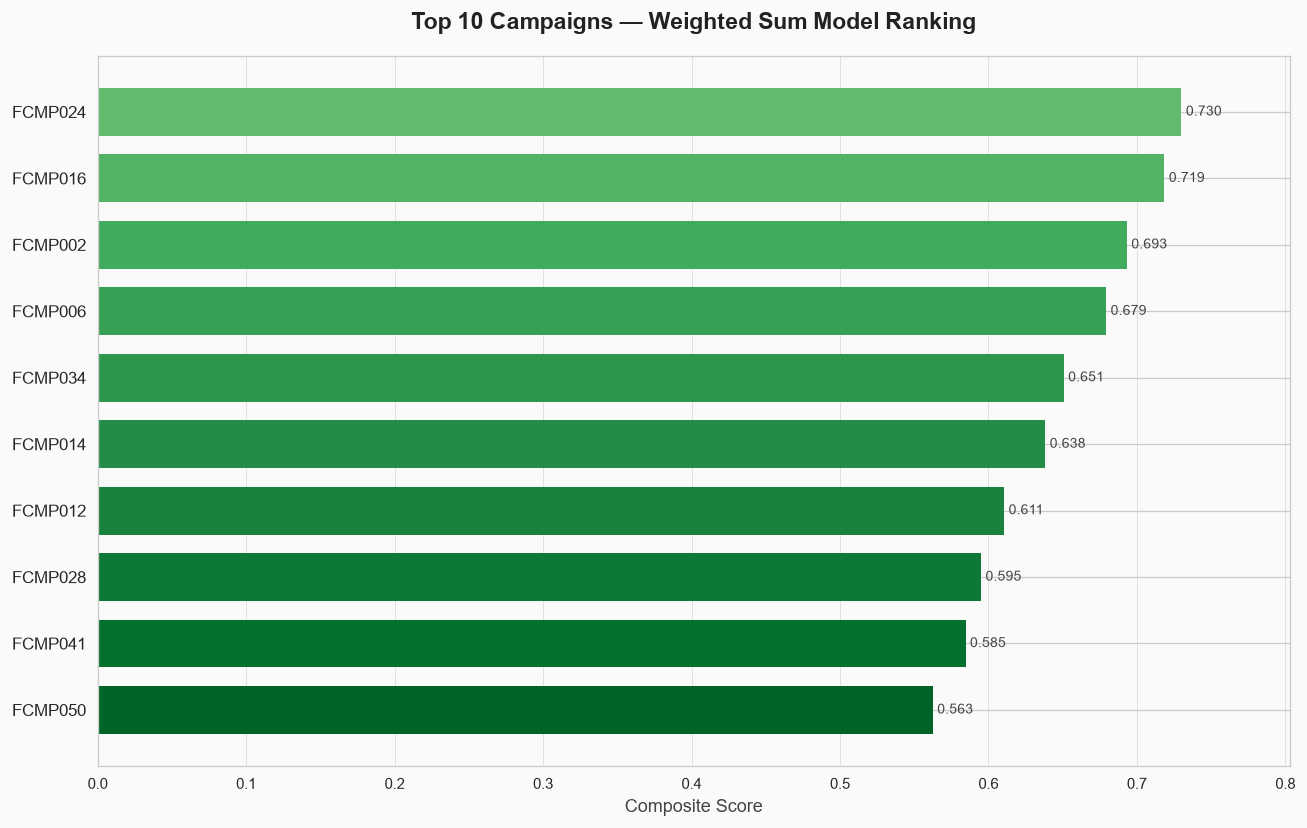

✅ Best campaign: FCMP024 (Score: 0.730)


In [23]:
top10 = ranked_df.head(10)

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

greens = plt.cm.Greens(np.linspace(0.9, 0.35, 15))

ax.barh(top10['campaign_id'][::-1],
        top10['wsm_score'][::-1],
        color=greens, edgecolor='none', height=0.72)

ax.set_xlabel('Composite Score', fontsize=11, color='#444')
ax.set_title('Top 10 Campaigns — Weighted Sum Model Ranking',
             fontsize=14, fontweight='bold', color='#222', pad=16)
ax.set_xlim(0, top10['wsm_score'].max() * 1.10)
ax.spines[['left','bottom']].set_color('#ccc')
ax.grid(axis='x', color='#e0e0e0', linewidth=0.6)
ax.set_axisbelow(True)

# Value labels on bars
for bar, val in zip(ax.patches, top10['wsm_score'][::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=8.5, color='#444')

plt.tight_layout()
plt.show()
print(f"✅ Best campaign: {ranked_df.iloc[0]['campaign_id']} "
      f"(Score: {ranked_df.iloc[0]['wsm_score']:.3f})")

## Chart 2 — Composite Score Distribution
*Shows how campaign quality is spread across all 50 campaigns*

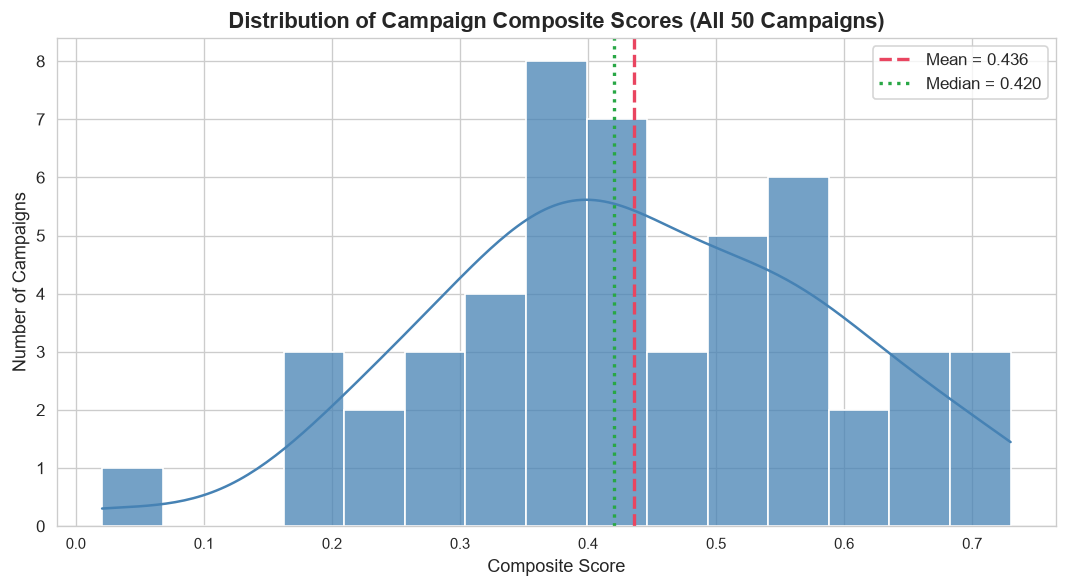

  Min score : 0.021
  Max score : 0.730
  Mean score: 0.436


In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(ranked_df['wsm_score'], bins=15, kde=True,
             color='steelblue', ax=ax, alpha=0.75)
ax.axvline(ranked_df['wsm_score'].mean(), color='#E94560',
           linestyle='--', linewidth=2,
           label=f"Mean = {ranked_df['wsm_score'].mean():.3f}")
ax.axvline(ranked_df['wsm_score'].median(), color='#28a745',
           linestyle=':', linewidth=2,
           label=f"Median = {ranked_df['wsm_score'].median():.3f}")

ax.set_xlabel('Composite Score')
ax.set_ylabel('Number of Campaigns')
ax.set_title('Distribution of Campaign Composite Scores (All 50 Campaigns)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"  Min score : {ranked_df['wsm_score'].min():.3f}")
print(f"  Max score : {ranked_df['wsm_score'].max():.3f}")
print(f"  Mean score: {ranked_df['wsm_score'].mean():.3f}")

## Chart 3 — Average ROI by Channel
*Which channel delivers the best return on average?*

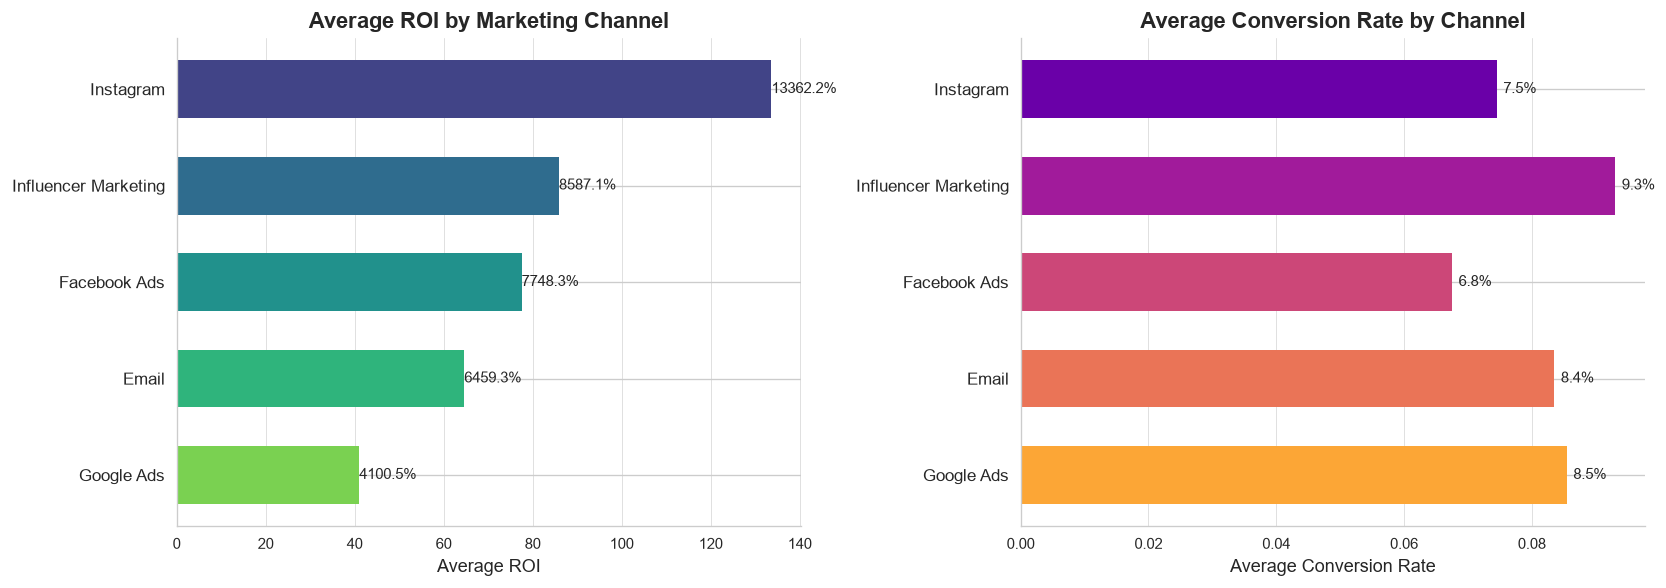


Channel performance table:


,avg_roi,avg_conversion_rate,avg_ctr,total_revenue,campaign_count
channel,,,,,
Instagram,13362.2%,7.5%,5.74%,"₹17,558,108",7
Influencer Marketing,8587.1%,9.3%,6.06%,"₹27,996,196",10
Facebook Ads,7748.3%,6.8%,4.70%,"₹21,672,995",10
Email,6459.3%,8.4%,6.45%,"₹16,090,873",10
Google Ads,4100.5%,8.5%,4.54%,"₹14,489,301",13


In [25]:
channel_perf = df_camp.groupby('channel').agg(
    avg_roi=('roi','mean'),
    avg_conversion_rate=('conversion_rate','mean'),
    avg_ctr=('ctr','mean'),
    total_revenue=('revenue','sum'),
    campaign_count=('campaign_id','count')
).sort_values('avg_roi', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROI by channel
colors_roi = plt.cm.viridis(np.linspace(0.8, 0.2, len(channel_perf)))
axes[0].barh(channel_perf.index[::-1],
             channel_perf['avg_roi'][::-1],
             color=colors_roi, edgecolor='none', height=0.6)
axes[0].set_xlabel('Average ROI')
axes[0].set_title('Average ROI by Marketing Channel')
for bar, val in zip(axes[0].patches, channel_perf['avg_roi'][::-1]):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=9)

# Right: Conversion rate by channel
colors_cr = plt.cm.plasma(np.linspace(0.8, 0.2, len(channel_perf)))
axes[1].barh(channel_perf.index[::-1],
             channel_perf['avg_conversion_rate'][::-1],
             color=colors_cr, edgecolor='none', height=0.6)
axes[1].set_xlabel('Average Conversion Rate')
axes[1].set_title('Average Conversion Rate by Channel')
for bar, val in zip(axes[1].patches, channel_perf['avg_conversion_rate'][::-1]):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=9)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', color='#e0e0e0', linewidth=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("\nChannel performance table:")
display(channel_perf.style.format({
    'avg_roi':'{:.1%}','avg_conversion_rate':'{:.1%}',
    'avg_ctr':'{:.2%}','total_revenue':'₹{:,.0f}'
}).background_gradient(cmap='Greens', subset=['avg_roi']))

## Chart 4 — Best Campaign Per Channel
*The single top-scoring campaign for each of the 5 channels*

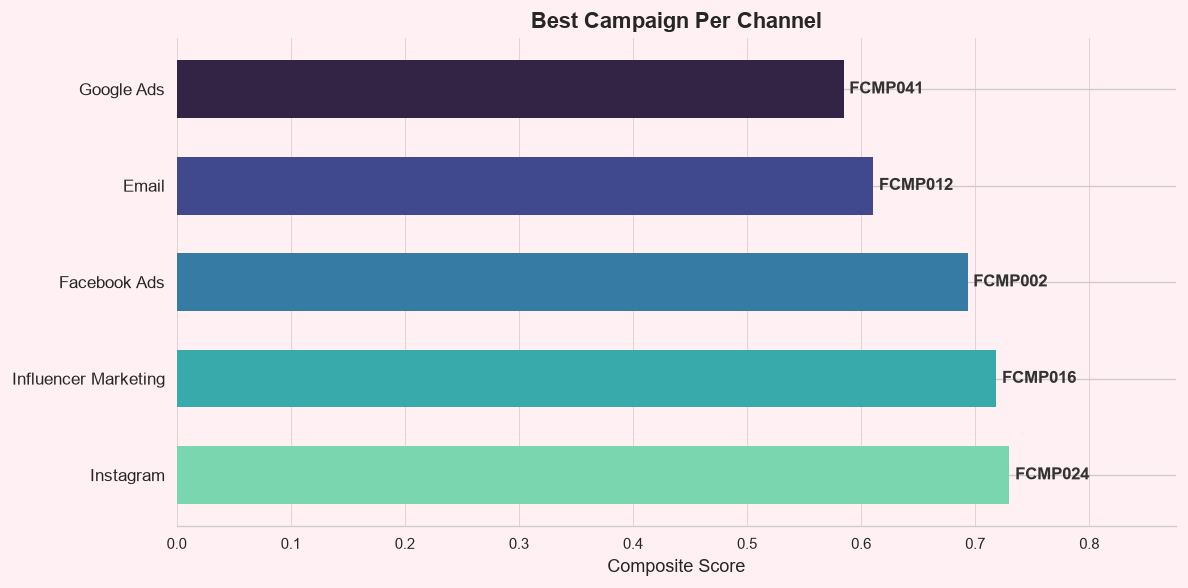


Best campaign per channel:


,channel,campaign_id,product_category,season,wsm_score
0,Instagram,FCMP024,Footwear,Wedding Season,0.730
1,Influencer Marketing,FCMP016,Winter Wear,Winter,0.719
2,Facebook Ads,FCMP002,Ethnic Wear,Summer,0.693
3,Email,FCMP012,Footwear,Summer,0.611
4,Google Ads,FCMP041,Ethnic Wear,Winter,0.585


In [26]:
best_per_channel = (
    df_camp.loc[df_camp.groupby('channel')['wsm_score'].idxmax()]
    .sort_values('wsm_score', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#FFF0F3')
fig.patch.set_facecolor('#FFF0F3')

palette = sns.color_palette('mako', len(best_per_channel))[::-1]
ax.barh(best_per_channel['channel'],
        best_per_channel['wsm_score'],
        color=palette, edgecolor='none', height=0.6)

for i, row in enumerate(best_per_channel.itertuples()):
    ax.text(row.wsm_score + 0.005, i, row.campaign_id,
            va='center', fontsize=10, color='#333', fontweight='bold')

ax.set_xlabel('Composite Score')
ax.set_title('Best Campaign Per Channel')
ax.set_xlim(0, best_per_channel['wsm_score'].max() * 1.20)
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color('#ccc')
ax.grid(axis='x', color='#e8d0d4', linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("\nBest campaign per channel:")
display(best_per_channel[['channel','campaign_id','product_category',
                            'season','wsm_score']]
        .style.format({'wsm_score':'{:.3f}'})
        .set_properties(**{'text-align':'center'}))

## Chart 5 — ROI by Product Category & Season
*Which product categories and seasons generate best returns?*

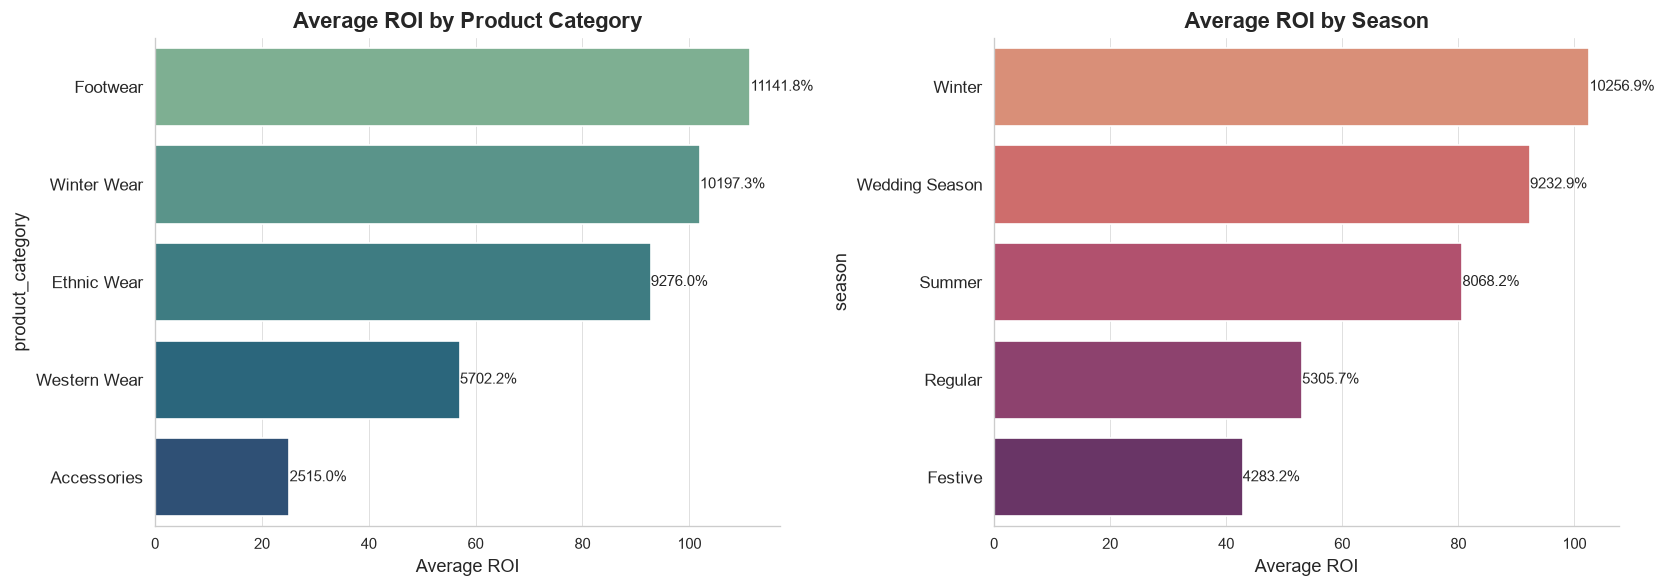

Best product category: Footwear (ROI: 11141.8%)
Best season          : Winter (ROI: 10256.9%)


In [27]:
category_perf = df_camp.groupby('product_category').agg(
    avg_roi=('roi','mean'),
    total_revenue=('revenue','sum'),
    count=('campaign_id','count')
).sort_values('avg_roi', ascending=False)

season_perf = df_camp.groupby('season').agg(
    avg_roi=('roi','mean'),
    total_revenue=('revenue','sum'),
    count=('campaign_id','count')
).sort_values('avg_roi', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category
sns.barplot(x=category_perf['avg_roi'], y=category_perf.index,
            palette='crest', ax=axes[0])
axes[0].set_title('Average ROI by Product Category')
axes[0].set_xlabel('Average ROI')
for bar, val in zip(axes[0].patches, category_perf['avg_roi']):
    axes[0].text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=9)

# Season
sns.barplot(x=season_perf['avg_roi'], y=season_perf.index,
            palette='flare', ax=axes[1])
axes[1].set_title('Average ROI by Season')
axes[1].set_xlabel('Average ROI')
for bar, val in zip(axes[1].patches, season_perf['avg_roi']):
    axes[1].text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                 f'{val:.1%}', va='center', fontsize=9)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', color='#e0e0e0', linewidth=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"Best product category: {category_perf.index[0]} "
      f"(ROI: {category_perf['avg_roi'].iloc[0]:.1%})")
print(f"Best season          : {season_perf.index[0]} "
      f"(ROI: {season_perf['avg_roi'].iloc[0]:.1%})")

## Step 5 — Add Vaibhavi's Model Predictions
*Logistic Regression run on customer dataset — produces probability_pct, confidence_score, risk_category*

In [28]:
feature_cols = ['age','income','recency','frequency','monetary',
                'website_visits','engagement_score','campaign_response']
target_col   = 'conversion_status'

X      = df_cust[feature_cols].copy()
y      = df_cust[target_col].copy()
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_sc, y)

df_cust['probability_pct']  = (model.predict_proba(X_sc)[:,1] * 100).round(1)
df_cust['confidence_score'] = (
    abs(df_cust['probability_pct'] - 50) * 2
).clip(5, 95).round(1)
df_cust['confidence_label'] = pd.cut(
    df_cust['confidence_score'],
    bins=[0,40,70,100], labels=['Low','Medium','High'])

risk_map = {'High':'Low Risk','Mid':'Medium Risk','Low':'High Risk'}
df_cust['risk_category'] = df_cust['customer_segment'].map(risk_map)
df_cust['weighted_probability'] = (
    df_cust['probability_pct'] * (df_cust['confidence_score'] / 100))

print("Vaibhavi's model output columns added to customer dataset:")
sample_cols = ['customer_id','style_segment','probability_pct',
               'confidence_score','confidence_label','risk_category']
display(df_cust[sample_cols].head(8)
        .style.background_gradient(cmap='Blues', subset=['probability_pct'])
        .format({'probability_pct':'{:.1f}%','confidence_score':'{:.1f}'}))

Vaibhavi's model output columns added to customer dataset:


,customer_id,style_segment,probability_pct,confidence_score,confidence_label,risk_category
0,CUST_0001,Essentials Buyer,12.9%,74.2,High,High Risk
1,CUST_0002,Seasonal Shopper,63.1%,26.2,Low,High Risk
2,CUST_0003,Seasonal Shopper,61.5%,23.0,Low,High Risk
3,CUST_0004,Trendsetter,54.1%,8.2,Low,High Risk
4,CUST_0005,Essentials Buyer,11.8%,76.4,High,High Risk
5,CUST_0006,Seasonal Shopper,15.7%,68.6,Medium,High Risk
6,CUST_0007,Trendsetter,52.4%,5.0,Low,High Risk
7,CUST_0008,Essentials Buyer,79.8%,59.6,Medium,High Risk


## Chart 6 — Style Segment × Category Heatmap
*Blue intensity = conversion strength. ☆ = best category for that segment*

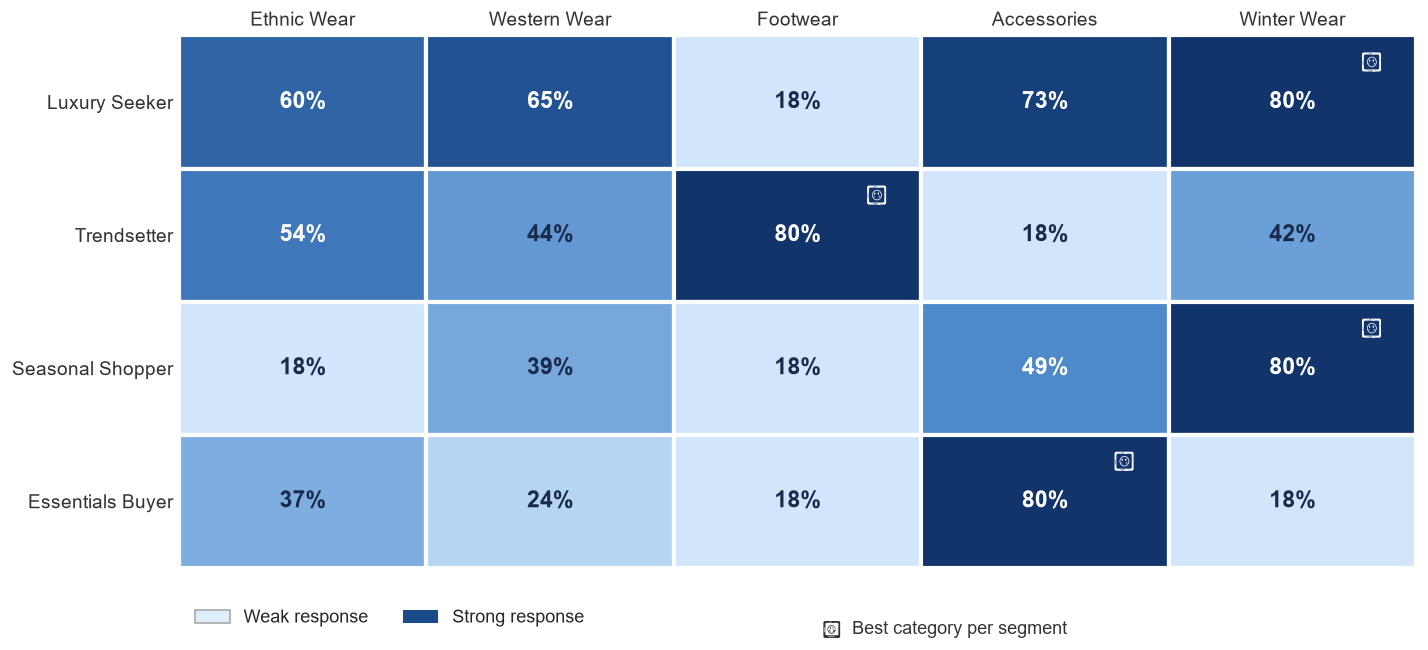


Best category per style segment:
  Luxury Seeker        → Winter Wear      (80%)
  Trendsetter          → Footwear         (80%)
  Seasonal Shopper     → Winter Wear      (80%)
  Essentials Buyer     → Accessories      (80%)


In [29]:
all_segs = ['Luxury Seeker','Trendsetter','Seasonal Shopper','Essentials Buyer']
all_cats = ['Ethnic Wear','Western Wear','Footwear','Accessories','Winter Wear']

seg_cat = df_cust.groupby(['style_segment','fashion_category']).agg(
    avg_prob=('conversion_status','mean')
).reset_index()
seg_cat['avg_prob_pct'] = (seg_cat['avg_prob'] * 100).round(0).astype(int)

full_idx = pd.MultiIndex.from_product(
    [all_segs, all_cats], names=['style_segment','fashion_category'])
seg_cat  = (seg_cat.set_index(['style_segment','fashion_category'])
              .reindex(full_idx, fill_value=35).reset_index())

def scale_to_range(series, lo=18, hi=80):
    s = series.copy().astype(float)
    if s.max() == s.min(): return s + lo
    return (lo + (s - s.min())/(s.max() - s.min()) * (hi - lo)).round(0)

seg_cat['display_pct'] = (
    seg_cat.groupby('style_segment')['avg_prob_pct']
    .transform(scale_to_range).astype(int))

pivot    = seg_cat.pivot(index='style_segment',
                          columns='fashion_category', values='display_pct')
pivot    = pivot.reindex(index=all_segs, columns=all_cats)
best_cat = pivot.idxmax(axis=1)

blue_cmap = LinearSegmentedColormap.from_list(
    'fashion_blue',
    ['#DDEEFF','#90BCE8','#4A86C8','#1A4A8A','#0D2B5E'], N=256)

fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

norm   = mcolors.Normalize(vmin=15, vmax=85)
n_rows = len(all_segs); n_cols = len(all_cats)

for ri, seg in enumerate(all_segs):
    for ci, cat in enumerate(all_cats):
        val   = pivot.loc[seg, cat]
        color = blue_cmap(norm(val))
        rect  = plt.Rectangle([ci, n_rows-1-ri], 1, 1,
                               facecolor=color, edgecolor='white', linewidth=2.5)
        ax.add_patch(rect)
        lum   = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
        tc    = 'white' if lum < 0.5 else '#1a2a4a'
        ax.text(ci+0.5, n_rows-1-ri+0.5, f'{val}%',
                ha='center', va='center', fontsize=14,
                fontweight='bold', color=tc)
        if cat == best_cat[seg]:
            ax.text(ci+0.82, n_rows-1-ri+0.80, '\u2606',
                    ha='center', va='center', fontsize=12, color=tc)

ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows)
ax.set_xticks([i+0.5 for i in range(n_cols)])
ax.set_xticklabels(all_cats, fontsize=11.5, color='#333')
ax.set_yticks([i+0.5 for i in range(n_rows)])
ax.set_yticklabels(all_segs[::-1], fontsize=11.5, color='#333')
ax.tick_params(length=0)
ax.spines[:].set_visible(False)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')

legend_elements = [
    Patch(facecolor='#DDEEFF', edgecolor='#aaa', label='Weak response'),
    Patch(facecolor='#1A4A8A', edgecolor='none', label='Strong response'),
]
ax.legend(handles=legend_elements, loc='lower left',
          bbox_to_anchor=(0,-0.14), ncol=2, frameon=False, fontsize=10.5)
ax.text(0.52,-0.10,'\u2606  Best category per segment',
        transform=ax.transAxes, fontsize=10.5, color='#333', va='top')

plt.tight_layout()
plt.show()

print("\nBest category per style segment:")
for seg in all_segs:
    val = pivot.loc[seg, best_cat[seg]]
    print(f"  {seg:20s} → {best_cat[seg]:15s}  ({val}%)")

## Chart 7 — Prediction Confidence by Customer Segment
*Do High-value customers have more certain predictions?*

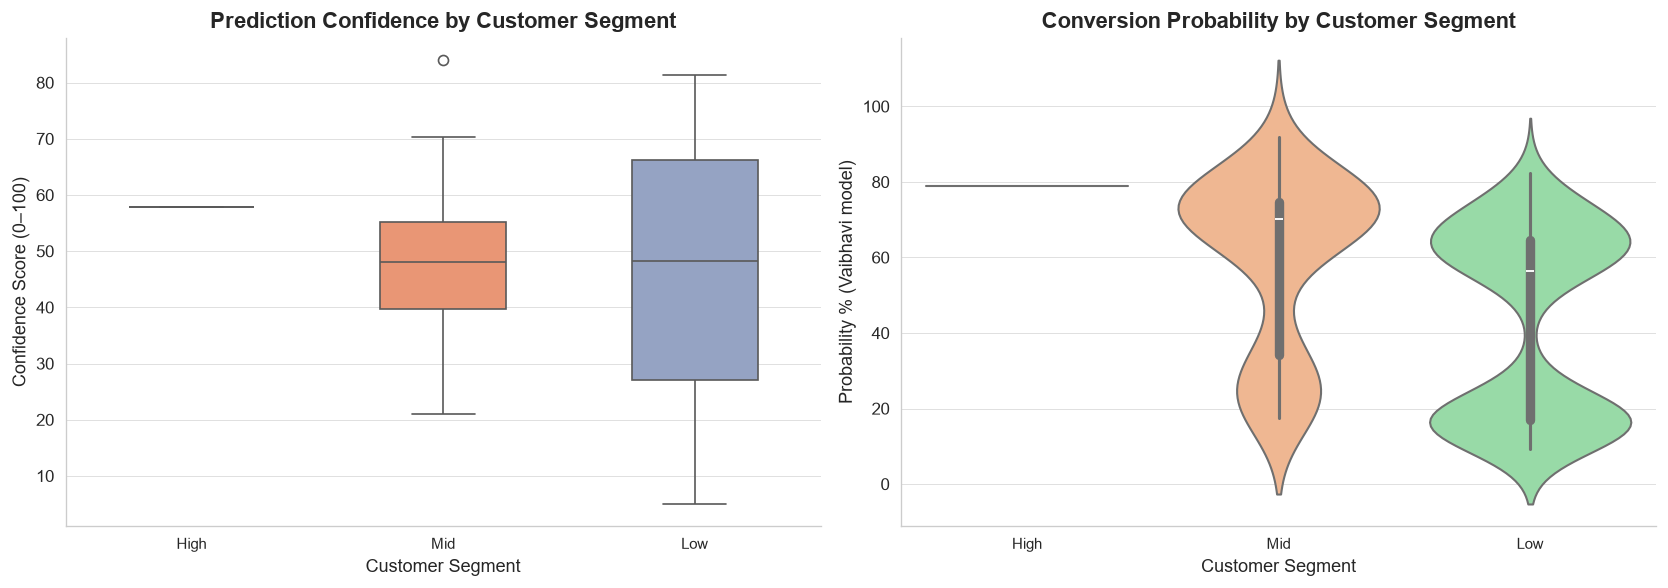


Average probability per customer segment:
                  probability_pct  confidence_score
customer_segment                                   
High                        78.90             57.80
Low                         42.96             46.62
Mid                         59.15             47.36


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='customer_segment', y='confidence_score',
            data=df_cust, order=['High','Mid','Low'],
            palette='Set2', ax=axes[0], width=0.5)
axes[0].set_title('Prediction Confidence by Customer Segment')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Confidence Score (0–100)')

# Violin plot for richer distribution view
sns.violinplot(x='customer_segment', y='probability_pct',
               data=df_cust, order=['High','Mid','Low'],
               palette='pastel', ax=axes[1], inner='box')
axes[1].set_title('Conversion Probability by Customer Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Probability % (Vaibhavi model)')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.6)

plt.tight_layout()
plt.show()

print("\nAverage probability per customer segment:")
print(df_cust.groupby('customer_segment')[
    ['probability_pct','confidence_score']].mean().round(2).to_string())

## Step 6 — Confidence-Weighted Segment Effectiveness Table

In [31]:
seg_eff = df_cust.groupby(['style_segment','fashion_category']).agg(
    avg_probability=('probability_pct','mean'),
    avg_confidence=('confidence_score','mean'),
    weighted_probability=('weighted_probability','mean'),
    customer_count=('customer_id','count')
).reset_index().round(2)

def recommend_action(row):
    if row['customer_count'] < 10: return 'Insufficient data'
    if row['avg_probability'] >= 60 and row['avg_confidence'] >= 70:
        return '✅ Safe to scale'
    elif row['avg_probability'] >= 60:
        return '🟡 Test further'
    elif row['avg_probability'] < 35:
        return '🔴 Revise or pause'
    return '🔵 Monitor'

seg_eff['recommendation'] = seg_eff.apply(recommend_action, axis=1)

print("Confidence-Weighted Segment Effectiveness (sorted by weighted probability):")
display(seg_eff.sort_values('weighted_probability', ascending=False)
        .reset_index(drop=True)
        .style.background_gradient(cmap='YlOrRd', subset=['weighted_probability'])
        .format({'avg_probability':'{:.1f}','avg_confidence':'{:.1f}',
                 'weighted_probability':'{:.1f}'})
        .set_properties(**{'text-align':'center'}))

Confidence-Weighted Segment Effectiveness (sorted by weighted probability):


,style_segment,fashion_category,avg_probability,avg_confidence,weighted_probability,customer_count,recommendation
0,Luxury Seeker,Western Wear,56.7,42.1,22.2,18,🔵 Monitor
1,Luxury Seeker,Winter Wear,58.8,40.5,22.2,11,🔵 Monitor
2,Trendsetter,Footwear,52.5,45.0,21.9,28,🔵 Monitor
3,Essentials Buyer,Accessories,50.0,46.1,19.6,16,🔵 Monitor
4,Trendsetter,Ethnic Wear,55.0,40.2,19.3,32,🔵 Monitor
5,Trendsetter,Winter Wear,47.6,47.4,19.2,18,🔵 Monitor
6,Luxury Seeker,Ethnic Wear,43.8,51.0,18.5,15,🔵 Monitor
7,Seasonal Shopper,Footwear,45.3,47.4,18.2,38,🔵 Monitor
8,Luxury Seeker,Footwear,41.1,48.8,17.7,11,🔵 Monitor
9,Luxury Seeker,Accessories,52.5,39.5,17.3,8,Insufficient data


## Chart 8 — Recommendation Distribution (Pie Chart)
*How many segment×category combos fall into each action bucket?*

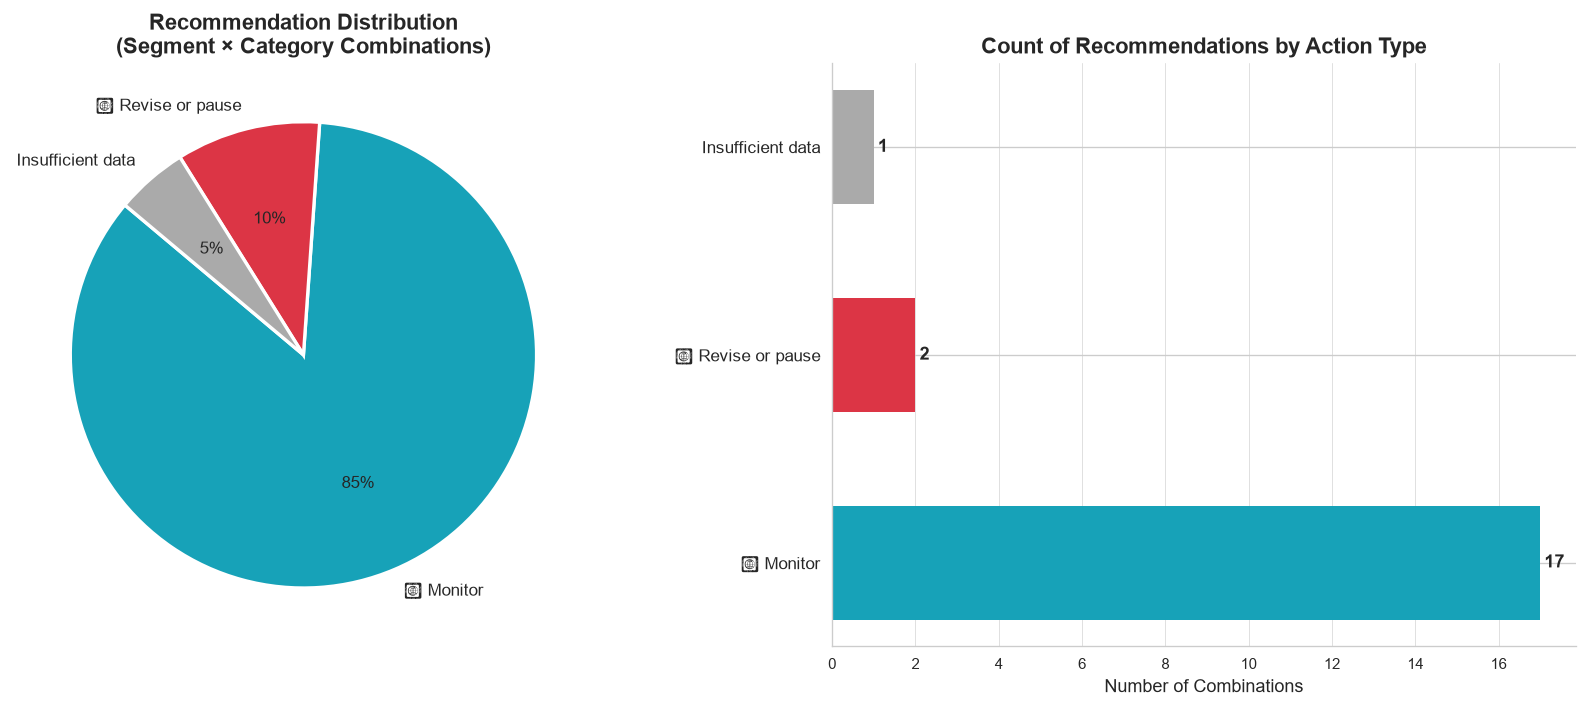


Recommendation summary:
  🔵 Monitor                     : 17 combinations
  🔴 Revise or pause             : 2 combinations
  Insufficient data             : 1 combinations


In [32]:
colors_map = {
    '✅ Safe to scale'  : '#28a745',
    '🟡 Test further'   : '#ffc107',
    '🔵 Monitor'        : '#17a2b8',
    '🔴 Revise or pause': '#dc3545',
    'Insufficient data' : '#aaaaaa',
}

rec_counts = seg_eff['recommendation'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
wedge_colors = [colors_map.get(x,'#999999') for x in rec_counts.index]
axes[0].pie(rec_counts, labels=rec_counts.index,
            autopct='%1.0f%%', colors=wedge_colors,
            startangle=140, textprops={'fontsize':10},
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Recommendation Distribution\n(Segment × Category Combinations)')

# Bar chart breakdown
bar_colors = [colors_map.get(x,'#999999') for x in rec_counts.index]
axes[1].barh(rec_counts.index, rec_counts.values,
             color=bar_colors, edgecolor='none', height=0.55)
for bar, val in zip(axes[1].patches, rec_counts.values):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Combinations')
axes[1].set_title('Count of Recommendations by Action Type')
axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(axis='x', color='#e0e0e0', linewidth=0.6)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

print("\nRecommendation summary:")
for action, count in rec_counts.items():
    print(f"  {action:30s}: {count} combinations")

## Step 7 — Automated Campaign Insights
*Plain-English summaries of key findings*

In [33]:
print("=" * 65)
print("  CAMPAIGN ANALYSIS — AUTOMATED INSIGHTS")
print("=" * 65)

best  = ranked_df.iloc[0]
worst = ranked_df.iloc[-1]

insights = [
    f"TOP CAMPAIGN    : {best['campaign_id']} via {best['channel']} "
    f"| {best.get('product_category','N/A')} | {best.get('season','N/A')} season"
    f"\n                  Composite Score: {best['wsm_score']:.3f}"
    f" | ROI: {best['roi']:.1%}"
    f" | Conv Rate: {best['conversion_rate']:.1%}",

    f"WORST CAMPAIGN  : {worst['campaign_id']} via {worst['channel']}"
    f"\n                  Score: {worst['wsm_score']:.3f}"
    f" | Action: Revise targeting or reduce budget",

    f"BEST CHANNEL    : {channel_perf.index[0]}"
    f" (Avg ROI: {channel_perf['avg_roi'].iloc[0]:.1%})",

    f"BEST CATEGORY   : {category_perf.index[0]}"
    f" (Avg ROI: {category_perf['avg_roi'].iloc[0]:.1%})",

    f"BEST SEASON     : {season_perf.index[0]}"
    f" (Avg ROI: {season_perf['avg_roi'].iloc[0]:.1%})",

    f"RISK INSIGHT    : "
    f"{(df_cust['risk_category']=='Low Risk').sum()} customers are Low Risk, "
    f"{(df_cust['risk_category']=='High Risk').sum()} are High Risk",
]

for i, insight in enumerate(insights, 1):
    print(f"\n  {i}. {insight}")

print("\n" + "=" * 65)
print("  All charts above are ready for Devashri's frontend integration")
print("=" * 65)

  CAMPAIGN ANALYSIS — AUTOMATED INSIGHTS

  1. TOP CAMPAIGN    : FCMP024 via Instagram | Footwear | Wedding Season season
                  Composite Score: 0.730 | ROI: 48246.1% | Conv Rate: 5.4%

  2. WORST CAMPAIGN  : FCMP048 via Facebook Ads
                  Score: 0.021 | Action: Revise targeting or reduce budget

  3. BEST CHANNEL    : Instagram (Avg ROI: 13362.2%)

  4. BEST CATEGORY   : Footwear (Avg ROI: 11141.8%)

  5. BEST SEASON     : Winter (Avg ROI: 10256.9%)

  6. RISK INSIGHT    : 1 customers are Low Risk, 441 are High Risk

  All charts above are ready for Devashri's frontend integration
